# 08 — Refined axes validity

Build atomic constructs and test coverage / coherence **before** seeing outcomes.
Measurement gates: ≥3 topics → viable; 1–2 → thin; 0 → unmeasurable.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh

ctx = nh.setup("08_refined_axes_validity")
cfg = ctx.cfg

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity


In [2]:
frame = nh.load_refined_frame(cfg, mode="strict")
manifest = pd.read_parquet(cfg.output_path("book_features_dir") / "refined_frame_manifest.parquet")
display(manifest.sort_values("nonzero_books", ascending=False).head(40))
ctx.save_table(manifest, "construct_coverage")

,column,nonzero_books,mean,median
39,RAX_h1_emotional_side,15994,0.0831,0.0801
32,RAX_relational_darkness,15994,0.0659,0.0638
48,RAX_h5_relational_darkness_side,15994,0.0659,0.0638
9,RAX_emotional_reassurance,15994,0.0629,0.0595
37,RAX_tenderness_core,15992,0.0732,0.0711
49,RAX_h5_tenderness_side,15992,0.0732,0.0711
43,RAX_h3_emotional_side,15991,0.0303,0.0281
10,RAX_emotional_security,15991,0.0303,0.0281
45,RAX_social_presentation,15991,0.0206,0.0193
20,RAX_individual_distress,15988,0.0222,0.0202


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/tables/construct_coverage.csv  (63 rows)


## Measurement testability gates

Ported from Stage 10 NB04: zero mapped topics → unmeasurable; one–two → thin;
three or more → viable. Primary ratios and headline atoms are gated before NB09.

In [3]:
coverage = nh.load_construct_coverage(cfg)
assert coverage, "Run pipeline 07 first so construct_coverage.json exists"

gate_rows = []
for section, blob in (
    ("ratio", coverage.get("ratios") or {}),
    ("composite", coverage.get("composites") or {}),
    ("atom", coverage.get("atoms") or {}),
):
    for name, info in blob.items():
        gate_rows.append(
            {
                "level": section,
                "feature": name,
                "n_topics": info.get("n_topics")
                if "n_topics" in info
                else info.get("numerator_topics"),
                "n_topics_den": info.get("denominator_topics"),
                "gate": info.get("gate"),
            }
        )
gates = pd.DataFrame(gate_rows).sort_values(["gate", "feature"])
display(gates)
ctx.save_table(gates, "measurement_gates")

headline = [
    "RLR_emotional_vs_explicit",
    "RAX_h2_strict",
    "RAX_h2_broad",
    "RLR_emotional_vs_material_security",
    "RAX_appearance_grooming",
    "RAX_status_display",
    "RAX_h4_protection_side",
    "RLR_protection_vs_control",
    "RLR_darkness_vs_tenderness",
    "RAX_external_danger_crisis",
    "RAX_relational_darkness",
    "RAX_tenderness_core",
    "RARC",
]
headline_gates = pd.DataFrame(
    [
        {
            "feature": f,
            "measurement_gate": nh.gate_for_feature(coverage, f),
        }
        for f in headline
    ]
)
display(headline_gates)
ctx.save_table(headline_gates, "headline_measurement_gates")
print(
    "Unmeasurable/thin axes must not be reported as ordinary null results in notebook 09."
)

,level,feature,n_topics,n_topics_den,gate
19,atom,RAX_coercive_sexuality,1,NaN,thin
21,atom,RAX_commitment_symbols,1,NaN,thin
23,atom,RAX_emotional_intimacy,2,NaN,thin
26,atom,RAX_erotic_escalation,1,NaN,thin
30,atom,RAX_external_protection,1,NaN,thin
7,composite,RAX_h2_broad,1,NaN,thin
9,composite,RAX_h3_material_side,1,NaN,thin
12,composite,RAX_h4_possession_side,2,NaN,thin
11,composite,RAX_h4_protection_side,1,NaN,thin
34,atom,RAX_housing_security,1,NaN,thin


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/tables/measurement_gates.csv  (54 rows)


,feature,measurement_gate
0,RLR_emotional_vs_explicit,viable
1,RAX_h2_strict,unmeasurable
2,RAX_h2_broad,thin
3,RLR_emotional_vs_material_security,thin
4,RAX_appearance_grooming,viable
5,RAX_status_display,unmeasurable
6,RAX_h4_protection_side,thin
7,RLR_protection_vs_control,thin
8,RLR_darkness_vs_tenderness,viable
9,RAX_external_danger_crisis,viable


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/tables/headline_measurement_gates.csv  (13 rows)
Unmeasurable/thin axes must not be reported as ordinary null results in notebook 09.


## Atomic construct distributions (no outcome conditioning)

In [4]:
atoms = [
    c
    for c in frame.columns
    if c.startswith("RAX_")
    and not c.startswith("RAX_h")
    and "begin" not in c
    and "end" not in c
]
usable = frame[frame.get("analysable", True) == True] if "analysable" in frame.columns else frame
summary = pd.DataFrame(
    {
        "construct": atoms,
        "pct_nonzero": [(usable[c] > 0).mean() * 100 for c in atoms],
        "mean": [usable[c].mean() for c in atoms],
        "median": [usable[c].median() for c in atoms],
        "p90": [usable[c].quantile(0.9) for c in atoms],
        "measurement_gate": [nh.gate_for_feature(coverage, c) for c in atoms],
    }
).sort_values("mean", ascending=False)
display(summary.round(4))
ctx.save_table(summary, "atomic_construct_summary")

,construct,pct_nonzero,mean,median,p90,measurement_gate
30,RAX_relational_darkness,99.9687,0.0659,0.0638,0.0893,viable
8,RAX_emotional_reassurance,99.9687,0.0629,0.0595,0.0851,viable
2,RAX_arc_rising,99.8937,0.0371,0.0358,0.0543,viable
9,RAX_emotional_security,99.9500,0.0303,0.0281,0.0429,viable
18,RAX_individual_distress,99.9312,0.0222,0.0202,0.0338,viable
36,RAX_social_presentation,99.9500,0.0206,0.0193,0.0310,viable
0,RAX_appearance_grooming,99.9125,0.0161,0.0150,0.0246,viable
22,RAX_nonexplicit_affection,99.2062,0.0133,0.0110,0.0272,viable
1,RAX_arc_falling,99.8750,0.0125,0.0116,0.0169,viable
12,RAX_external_danger_crisis,99.8187,0.0091,0.0067,0.0155,viable


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/tables/atomic_construct_summary.csv  (37 rows)


## Inter-construct correlations

  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/figures/construct_correlations.png


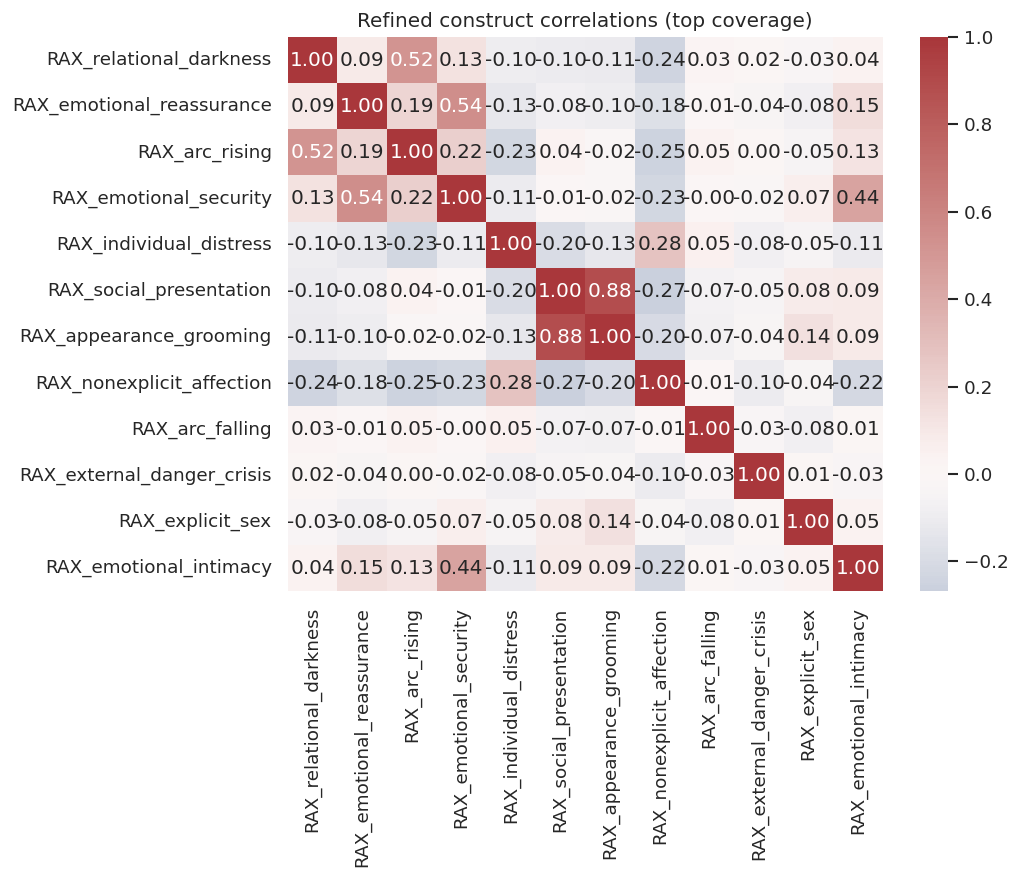

  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/tables/construct_correlations.csv  (12 rows)


In [5]:
top = summary.head(12)["construct"].tolist()
corr = usable[top].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Refined construct correlations (top coverage)")
ctx.save_figure(fig, "construct_correlations")
plt.show()
ctx.save_table(corr.reset_index(), "construct_correlations")

## Strict vs weighted agreement

In [6]:
strict = nh.load_refined_frame(cfg, "strict")
weighted = nh.load_refined_frame(cfg, "weighted")
common = [c for c in atoms if c in weighted.columns]
agree = []
for c in common:
    r = np.corrcoef(strict[c].fillna(0), weighted[c].fillna(0))[0, 1]
    agree.append({"construct": c, "corr_strict_weighted": float(r)})
agree_df = pd.DataFrame(agree).sort_values("corr_strict_weighted")
display(agree_df)
ctx.save_table(agree_df, "strict_vs_weighted_agreement")

/home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/.venv/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/.venv/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,construct,corr_strict_weighted
27,RAX_practical_care,0.4305
7,RAX_emotional_intimacy,0.5470
25,RAX_possessive_claiming,0.6110
33,RAX_sexual_tension,0.6236
14,RAX_external_protection,0.7026
24,RAX_physical_protection,0.7079
22,RAX_nonexplicit_affection,0.7255
12,RAX_external_danger_crisis,0.7365
18,RAX_individual_distress,0.7448
1,RAX_arc_falling,0.7463


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/tables/strict_vs_weighted_agreement.csv  (37 rows)


## Author concentration (top construct)

In [7]:
if "author_id" in usable.columns and top:
    c0 = top[0]
    by_auth = usable.groupby("author_id")[c0].mean().sort_values(ascending=False)
    print(f"Top construct {c0}: top author mean={by_auth.iloc[0]:.4f}, median author={by_auth.median():.4f}")
    print(f"Share of books from singleton authors: {(usable.groupby('author_id').size() == 1).mean():.1%}")

print("Validity checks complete — proceed to hypothesis tests in notebook 09.")

Top construct RAX_relational_darkness: top author mean=0.2303, median author=0.0629
Share of books from singleton authors: 64.8%
Validity checks complete — proceed to hypothesis tests in notebook 09.
